In [107]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [108]:
df = pd.read_pickle('/content/drive/MyDrive/df.pkl')

In [109]:
import pandas as pd
df = pd.read_pickle('/content/drive/MyDrive/df.pkl')
if 'Chine, continentale' in df.index:
    display(df.loc['Chine, continentale'])
else:
    print("'Chine' not found in the dataframe index.")

'Chine' not found in the dataframe index.


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, 1 to 234
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Pays                       141 non-null    object 
 1   Population                 141 non-null    float64
 2   Export                     141 non-null    float64
 3   Import                     141 non-null    float64
 4   Production                 141 non-null    float64
 5   Variation de stock         141 non-null    float64
 6   Stabilite                  141 non-null    float64
 7   Taux_electricite           141 non-null    float64
 8   Qualite_route              141 non-null    float64
 9   PIB                        141 non-null    float64
 10  Dependance import          141 non-null    float64
 11  Disponibilite_interieure   141 non-null    float64
 12  Consumption_kg_per_person  141 non-null    float64
 13  Import_x_Stabilite         141 non-null    float64
 14 

In [111]:
df = df.drop('z', axis=1)

In [112]:
names = df['Pays']
names

,Pays
1,Afrique du Sud
2,Albanie
3,Algérie
4,Allemagne
6,Angola
...,...
228,Uruguay
229,Vanuatu
231,Viet Nam
233,Zambie


In [113]:
features = df.columns
features

Index(['Pays', 'Population', 'Export', 'Import', 'Production',
       'Variation de stock', 'Stabilite', 'Taux_electricite', 'Qualite_route',
       'PIB', 'Dependance import', 'Disponibilite_interieure',
       'Consumption_kg_per_person', 'Import_x_Stabilite'],
      dtype='object')

In [114]:
X = df.values
X[:5]

array([['Afrique du Sud', 57009.756, 63.0, 514.0, 1667.0, 0.0, -0.28,
        84.4, 4.42, 6612.920015, 0.2427, 2118.0, 37.15153595816127,
        -143.92],
       ['Albanie', 2884.169, 0.0, 38.0, 13.0, 4.0, 0.37, 99.9, 4.3,
        4492.285003, 0.7451, 55.0, 19.069617626428965, 14.06],
       ['Algérie', 41389.189, 0.0, 2.0, 275.0, 0.0, -0.92, 99.5, 3.49,
        4080.111475, 0.0072, 277.0, 6.692568921802261, -1.84],
       ['Allemagne', 82658.409, 646.0, 842.0, 1514.0, -29.0, 0.57, 100.0,
        5.51, 45281.718651, 0.4924, 1681.0, 20.33670887616528, 479.94],
       ['Angola', 29816.766, 0.0, 277.0, 42.0, 0.0, -0.39, 42.9, 0.0,
        4039.176725, 0.8683, 319.0, 10.698678723239134, -108.03]],
      dtype=object)

In [115]:
type(X)

numpy.ndarray

In [116]:
X_numeric = df.drop(columns=['Pays']).values
X_scaled = StandardScaler().fit_transform(X_numeric)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([2.68444550e-01, 2.03772756e-01, 1.18266671e-01, 8.95541549e-02,
       8.19938605e-02, 6.26028530e-02, 5.73429601e-02, 3.85986742e-02,
       3.15841584e-02, 2.13415551e-02, 1.87169715e-02, 7.78083471e-03,
       7.41965735e-18])

In [117]:
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8,9,10,11,12
mean,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [185]:
n_components = 12

In [186]:
pca = PCA(n_components=n_components)

In [187]:
pca.fit(X_scaled)

PCA(n_components=12)

In [188]:
pca.explained_variance_ratio_

array([0.26844455, 0.20377276, 0.11826667, 0.08955415, 0.08199386,
       0.06260285, 0.05734296, 0.03859867, 0.03158416, 0.02134156,
       0.01871697, 0.00778083])

In [189]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([26.84, 20.38, 11.83,  8.96,  8.2 ,  6.26,  5.73,  3.86,  3.16,
        2.13,  1.87,  0.78])

In [190]:
scree_cum = scree.cumsum().round()
scree_cum

array([ 27.,  47.,  59.,  68.,  76.,  82.,  88.,  92.,  95.,  97.,  99.,
       100.])

In [191]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

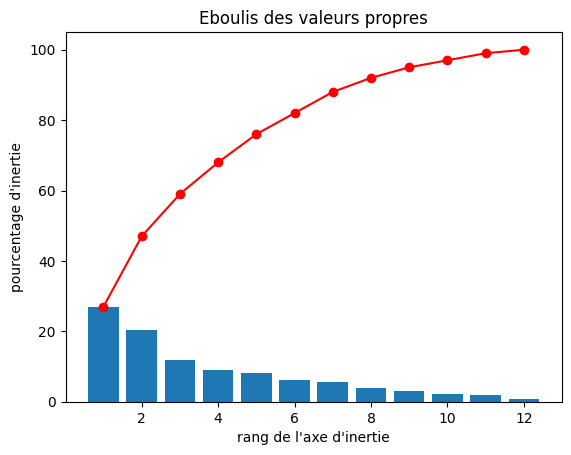

In [192]:
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

In [194]:
#On voit ici que près de 80% de la variance est comprise dans les 8 premières composantes, et près de 90% dans les 7 premières.

In [193]:
pcs = pca.components_
pcs

array([[ 1.98296368e-01,  4.12325793e-01,  2.28853331e-01,
         4.45217288e-01,  2.07975653e-01,  1.37230951e-01,
         2.37677021e-01,  2.54587562e-01,  2.72779113e-01,
        -4.90823059e-02,  4.59426241e-01,  1.82943149e-01,
         1.87947138e-01],
       [-2.59432471e-01, -2.40606979e-01,  1.89192269e-01,
        -3.09945288e-01,  2.11582091e-01,  4.54832957e-01,
         2.25575656e-01,  1.43845352e-01,  3.37410024e-01,
         2.71437186e-01, -2.81318796e-01,  1.92379913e-01,
         3.40666186e-01],
       [-1.10064043e-01,  6.65657184e-02, -4.01402614e-01,
         6.21740844e-02, -4.08930937e-01,  2.77882765e-01,
         3.43837084e-01, -1.42823794e-01,  1.79016276e-01,
        -8.41665969e-02, -6.95762424e-04,  4.70488077e-01,
        -4.18221186e-01],
       [-2.43117619e-01,  2.92953312e-01,  5.18196651e-02,
         1.50541322e-01,  1.31766842e-02,  4.45263946e-02,
        -2.60339685e-01, -5.63994051e-01, -1.64674069e-01,
         5.76631805e-01,  1.10791758e

In [195]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.198296,0.412326,0.228853,0.445217,0.207976,0.137231,0.237677,0.254588,0.272779,-0.049082,0.459426,0.182943,0.187947
1,-0.259432,-0.240607,0.189192,-0.309945,0.211582,0.454833,0.225576,0.143845,0.337410,0.271437,-0.281319,0.192380,0.340666
2,-0.110064,0.066566,-0.401403,0.062174,-0.408931,0.277883,0.343837,-0.142824,0.179016,-0.084167,-0.000696,0.470488,-0.418221
3,-0.243118,0.292953,0.051820,0.150541,0.013177,0.044526,-0.260340,-0.563994,-0.164674,0.576632,0.110792,0.222635,0.142264
4,-0.213776,-0.050386,-0.245003,0.005710,0.597177,0.030490,0.018234,-0.263763,-0.250479,-0.537942,0.020627,0.294519,0.157989
5,0.376249,-0.259249,0.485540,-0.108836,0.023315,-0.254405,0.426007,-0.205803,-0.305211,0.087876,-0.013630,0.371586,-0.124068
6,0.738380,-0.083663,-0.403336,-0.034910,-0.014327,0.275255,-0.040217,-0.252652,0.039112,0.071173,-0.061666,-0.061037,0.358262
7,-0.196855,0.224899,-0.255031,0.018594,-0.044833,-0.141347,0.697878,-0.018172,-0.289065,0.144705,-0.063302,-0.392935,0.270233
8,0.040688,0.077447,-0.237729,-0.024932,-0.092679,-0.038907,-0.172844,0.615921,-0.495384,0.193784,-0.077805,0.439970,0.182450
9,0.050986,-0.037375,0.113806,0.068473,0.208703,0.662182,0.021177,0.073379,-0.454035,0.101269,0.112114,-0.284400,-0.425008


In [129]:
features_for_pcs = df.drop(columns=['Pays']).columns
pcs.columns = features_for_pcs
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,Population,Export,Import,Production,Variation de stock,Stabilite,Taux_electricite,Qualite_route,PIB,Dependance import,Disponibilite_interieure,Consumption_kg_per_person,Import_x_Stabilite
F1,0.20,0.41,0.23,0.45,0.21,0.14,0.24,0.25,0.27,-0.05,0.46,0.18,0.19
F2,-0.26,-0.24,0.19,-0.31,0.21,0.45,0.23,0.14,0.34,0.27,-0.28,0.19,0.34
F3,-0.11,0.07,-0.40,0.06,-0.41,0.28,0.34,-0.14,0.18,-0.08,-0.00,0.47,-0.42
F4,-0.24,0.29,0.05,0.15,0.01,0.04,-0.26,-0.56,-0.16,0.58,0.11,0.22,0.14
F5,-0.21,-0.05,-0.25,0.01,0.60,0.03,0.02,-0.26,-0.25,-0.54,0.02,0.29,0.16
F6,0.38,-0.26,0.49,-0.11,0.02,-0.25,0.43,-0.21,-0.31,0.09,-0.01,0.37,-0.12
F7,0.74,-0.08,-0.40,-0.03,-0.01,0.28,-0.04,-0.25,0.04,0.07,-0.06,-0.06,0.36
F8,-0.20,0.22,-0.26,0.02,-0.04,-0.14,0.70,-0.02,-0.29,0.14,-0.06,-0.39,0.27


<Axes: >

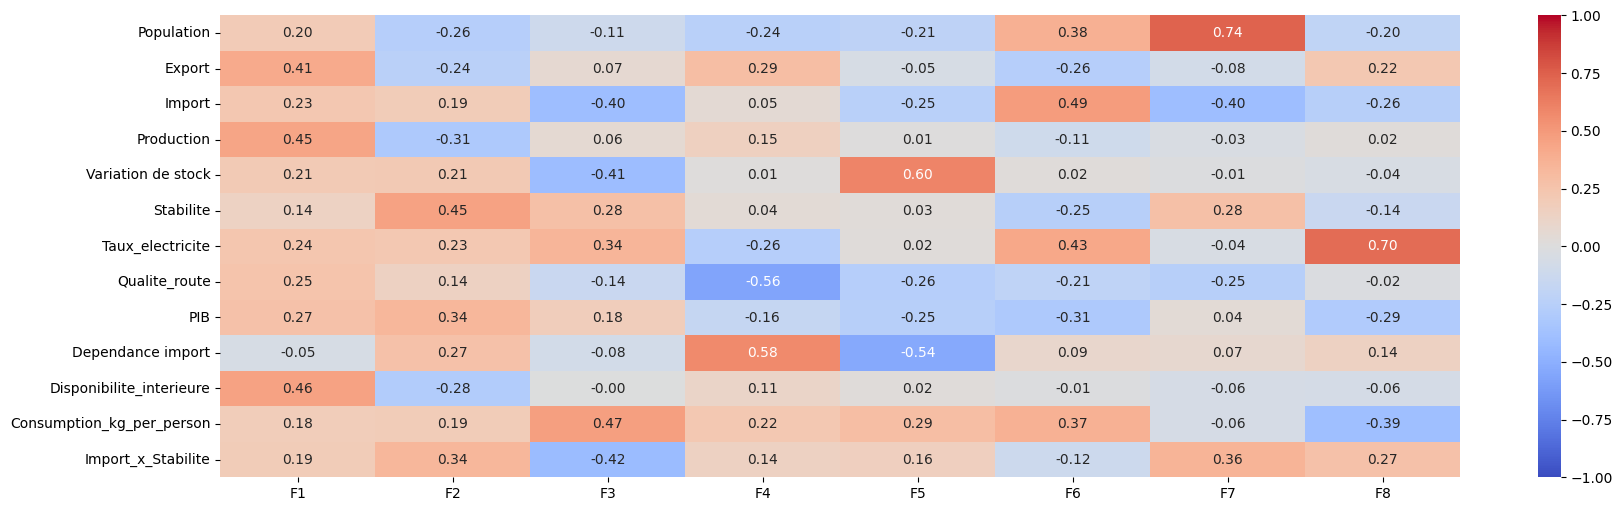

In [130]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

In [131]:
x, y = 0,1

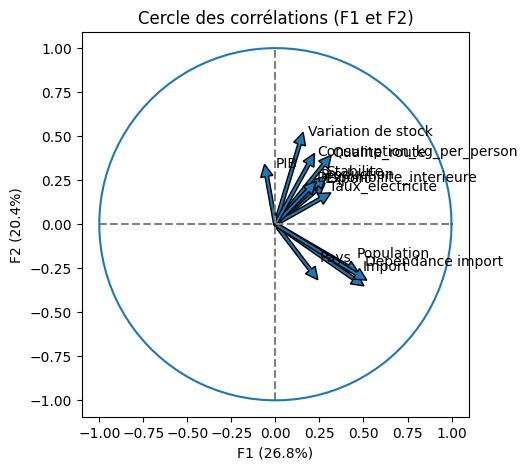

In [199]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             features[i])

# affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


# nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
plt.show(block=False)

In [202]:
#etudie F3 et F4
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(5,5))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

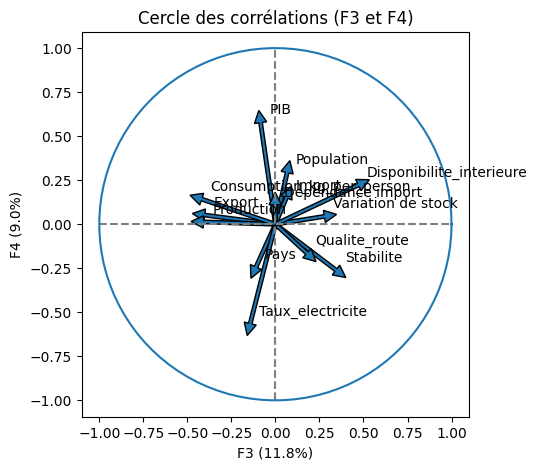

In [203]:
#Projection F3 et F4
correlation_graph(pca, (2,3), features)

In [135]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[ 0.85929362, -0.80511272, -0.49297275, -0.41203101, -0.55558822,
         1.53867818, -1.60043277, -1.02341224],
       [-0.44388541,  0.44299503,  0.04202005, -0.2046249 , -0.42854805,
        -0.01183151, -0.07143813,  0.8373981 ],
       [-0.77007086, -1.31490911, -0.50891713, -1.16714501,  0.22307501,
         0.2473504 , -0.32763348,  1.08719833],
       [ 3.15386175,  2.01373489, -2.24259377, -0.10627207, -1.76598358,
         0.62697884, -0.40930209, -0.0185731 ],
       [-1.57218771, -1.09885196, -1.18089539,  1.56241858, -0.69423824,
         0.39535437, -0.33630066, -0.9779239 ]])

In [136]:
x_y = (0,1)
x_y

(0, 1)

In [137]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[20,10],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()



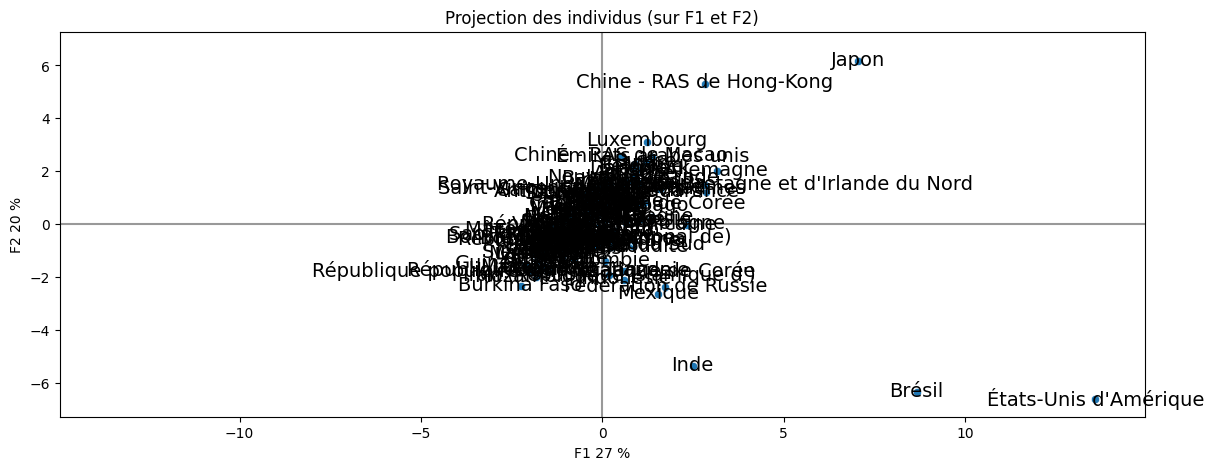

In [210]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, labels=names.tolist(), figsize=(14,5), marker="o")

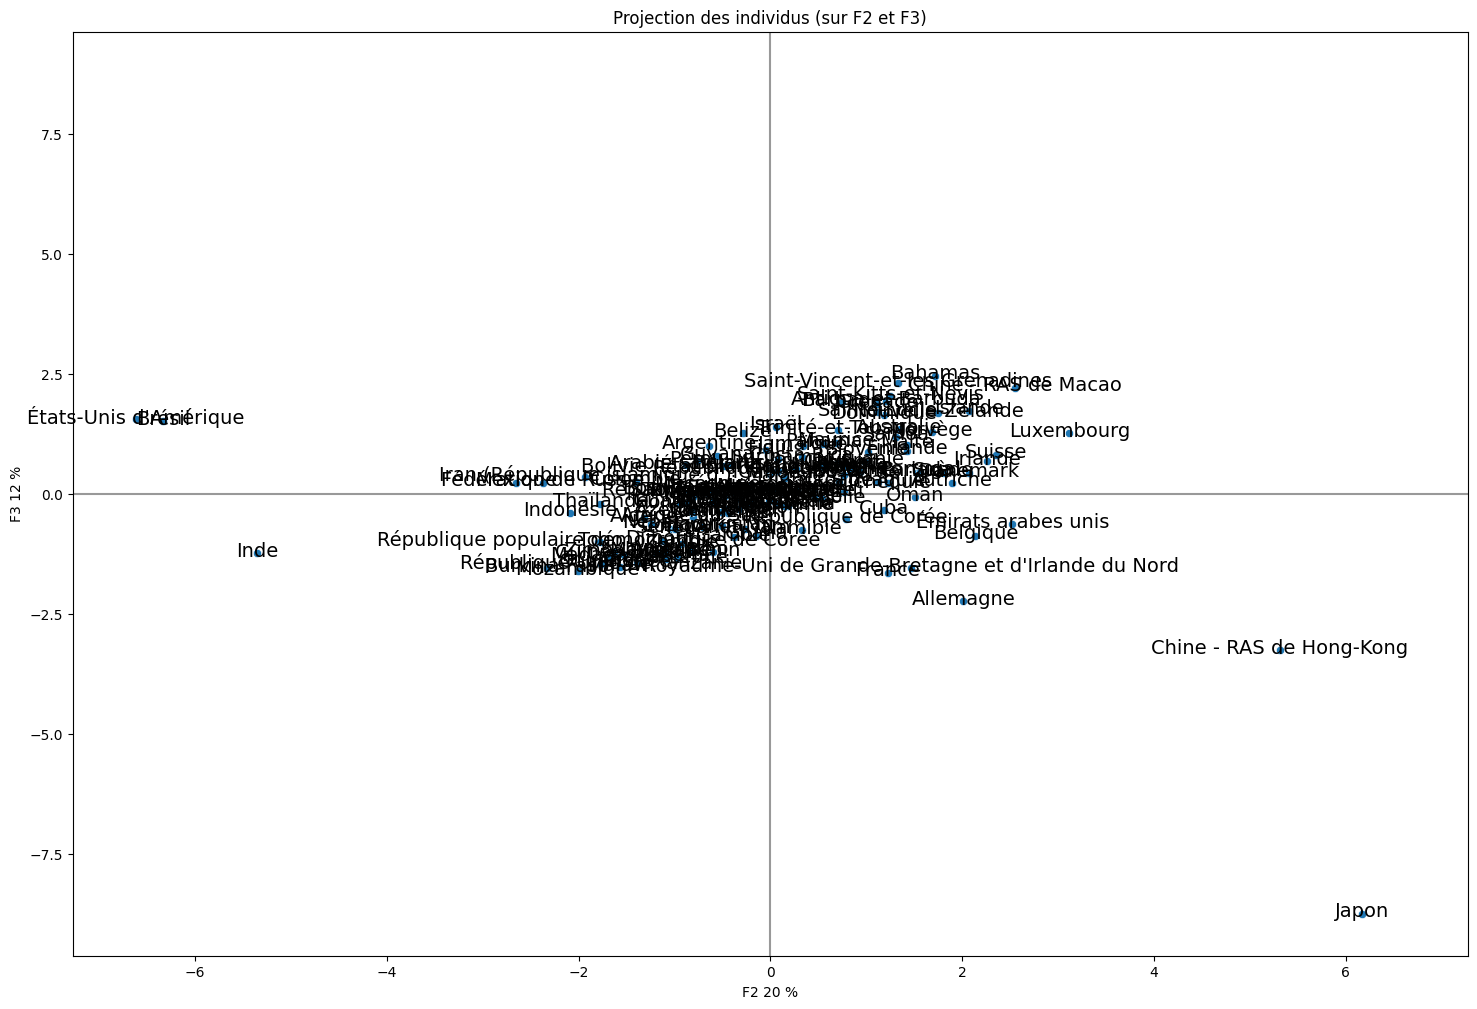

In [139]:
x_y = 1,2
display_factorial_planes(X_proj, x_y, pca, labels=names.tolist(), figsize=(18,12), marker="o")

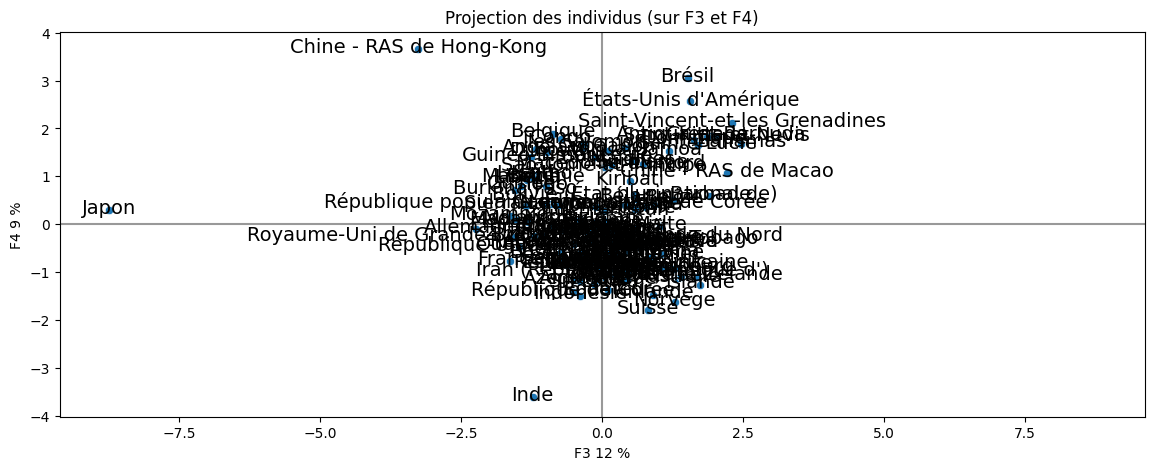

In [211]:
#projection de la variation de stock/importation quantité selon F3 (Courbe mieux représenté et mieux adapté sur l'activité)
x_y = 2,3
display_factorial_planes(X_proj, x_y, pca, labels=names.tolist(), figsize=(14,5), marker="o")

## tests K-Means

In [141]:

X = df.copy()
X.head()

,Pays,Population,Export,Import,Production,Variation de stock,Stabilite,Taux_electricite,Qualite_route,PIB,Dependance import,Disponibilite_interieure,Consumption_kg_per_person,Import_x_Stabilite
1,Afrique du Sud,57009.756,63.0,514.0,1667.0,0.0,-0.28,84.4,4.42,6612.920015,0.2427,2118.0,37.151536,-143.92
2,Albanie,2884.169,0.0,38.0,13.0,4.0,0.37,99.9,4.30,4492.285003,0.7451,55.0,19.069618,14.06
3,Algérie,41389.189,0.0,2.0,275.0,0.0,-0.92,99.5,3.49,4080.111475,0.0072,277.0,6.692569,-1.84
4,Allemagne,82658.409,646.0,842.0,1514.0,-29.0,0.57,100.0,5.51,45281.718651,0.4924,1681.0,20.336709,479.94
6,Angola,29816.766,0.0,277.0,42.0,0.0,-0.39,42.9,0.00,4039.176725,0.8683,319.0,10.698679,-108.03


In [142]:
Variables = X.values
X.columns

Index(['Pays', 'Population', 'Export', 'Import', 'Production',
       'Variation de stock', 'Stabilite', 'Taux_electricite', 'Qualite_route',
       'PIB', 'Dependance import', 'Disponibilite_interieure',
       'Consumption_kg_per_person', 'Import_x_Stabilite'],
      dtype='object')

In [143]:
intertia= []

In [144]:
k_list = range(1, 10)
list(k_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [145]:
for i in k_list :
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(X_scaled)
  intertia.append(kmeans.inertia_)

In [146]:
intertia

[1832.9999999999998,
 1533.026634570369,
 1264.2378689929524,
 1088.2512168737162,
 901.1458595017951,
 799.7772838238147,
 782.1923804535224,
 648.5493314771353,
 551.7262007077622]

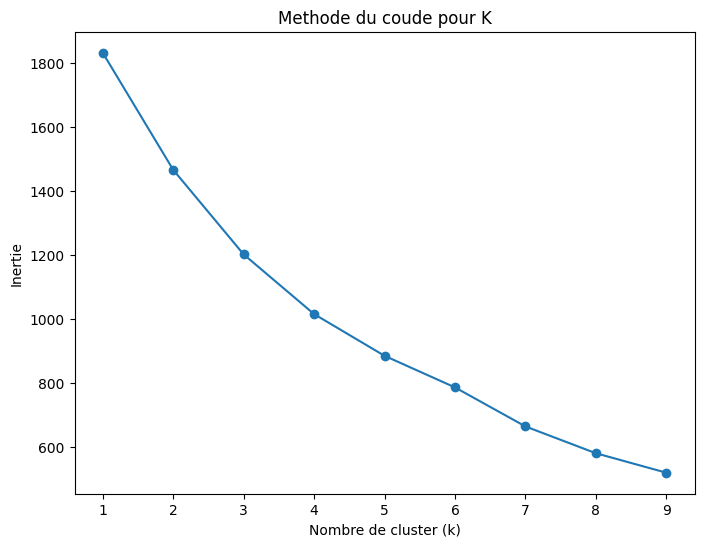

In [225]:
# Une liste vide pour enregistrer les inerties :
intertia_list = []

# Notre liste de nombres de clusters :
k_list = range(1, 10)

# Pour chaque nombre de clusters :
for k in k_list :

    # On instancie un k-means pour k clusters
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)

    # On entraine
    kmeans_model.fit(X_scaled)

    # On enregistre l'inertie obtenue :
    intertia_list.append(kmeans_model.inertia_)

fig, ax = plt.subplots(1,1,figsize=(8,6))

ax.set_ylabel("Inertie")
ax.set_xlabel("Nombre de cluster (k)")

ax.plot(k_list, intertia_list, marker='o')
ax.set_title("Methode du coude pour K")
plt.show()


In [148]:
#K-means après obtention du nombre de cluster(k)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X.drop(columns=['Pays']))

KMeans(n_clusters=6, n_init=10, random_state=42)

In [149]:
kmeans.labels_

array([0, 5, 0, 0, 5, 5, 0, 0, 5, 2, 2, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 3,
       5, 5, 5, 5, 2, 5, 2, 2, 5, 0, 5, 5, 5, 5, 2, 5, 5, 5, 2, 5, 0, 5,
       5, 4, 3, 5, 2, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 4,
       0, 2, 2, 2, 0, 5, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5,
       5, 0, 5, 5, 3, 5, 5, 5, 5, 5, 5, 2, 2, 5, 0, 5, 5, 0, 5, 0, 5, 5,
       5, 0, 5, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2, 5, 5, 5, 0,
       5, 5, 5, 5, 5, 5, 0, 5, 5], dtype=int32)

In [150]:
import string
num_clusters = kmeans.n_clusters
dd = {i: string.ascii_lowercase[i] for i in range(num_clusters)}
dd

{0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f'}

In [151]:
labels = [dd[i] for i in kmeans.labels_]
labels[:10]

['a', 'f', 'a', 'a', 'f', 'f', 'a', 'a', 'f', 'c']

In [152]:
X["cluster"] = labels
X


,Pays,Population,Export,Import,Production,Variation de stock,Stabilite,Taux_electricite,Qualite_route,PIB,Dependance import,Disponibilite_interieure,Consumption_kg_per_person,Import_x_Stabilite,cluster
1,Afrique du Sud,57009.756,63.0,514.0,1667.0,0.0,-0.28,84.4,4.42,6612.920015,0.2427,2118.0,37.151536,-143.92,a
2,Albanie,2884.169,0.0,38.0,13.0,4.0,0.37,99.9,4.30,4492.285003,0.7451,55.0,19.069618,14.06,f
3,Algérie,41389.189,0.0,2.0,275.0,0.0,-0.92,99.5,3.49,4080.111475,0.0072,277.0,6.692569,-1.84,a
4,Allemagne,82658.409,646.0,842.0,1514.0,-29.0,0.57,100.0,5.51,45281.718651,0.4924,1681.0,20.336709,479.94,a
6,Angola,29816.766,0.0,277.0,42.0,0.0,-0.39,42.9,0.00,4039.176725,0.8683,319.0,10.698679,-108.03,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,Uruguay,3436.641,3.0,3.0,33.0,0.0,1.04,99.8,3.28,19184.663384,0.0909,33.0,9.602400,3.12,f
229,Vanuatu,285.510,0.0,4.0,1.0,1.0,0.68,62.8,0.00,3159.860548,0.8000,6.0,21.015026,2.72,f
231,Viet Nam,94600.648,1.0,291.0,918.0,2.0,0.21,100.0,3.37,2956.109923,0.2409,1210.0,12.790610,61.11,a
233,Zambie,16853.599,1.0,12.0,49.0,0.0,0.14,40.3,3.63,1485.020061,0.2000,60.0,3.560070,1.68,f


In [153]:
Cluster_pays = X.groupby('cluster')['Pays'].apply(list)
display(Cluster_pays)

,Pays
cluster,
a,"[Afrique du Sud, Algérie, Allemagne, Arabie sa..."
b,[Inde]
c,"[Australie, Autriche, Belgique, Canada, Chine ..."
d,"[Brésil, Fédération de Russie, Japon, Mexique]"
e,"[États-Unis d'Amérique, Indonésie]"
f,"[Albanie, Angola, Antigua-et-Barbuda, Arménie,..."


In [154]:
#Nombre de pays par clusters
cluster_counts = X.groupby('cluster')['Pays'].count()
display(cluster_counts)

,Pays
cluster,
a,18
b,1
c,17
d,4
e,2
f,99


In [155]:
# On peut stocker nos centroids dans une variable :
centroids = kmeans.cluster_centers_
centroids

array([[ 5.61577072e+04,  2.25388889e+02,  2.36055556e+02,
         1.28222222e+03,  2.12777778e+01, -1.55000000e-01,
         9.14833333e+01,  4.36000000e+00,  1.71406397e+04,
         1.46627778e-01,  1.31416667e+03,  2.42341604e+01,
         2.51833333e+01],
       [ 1.33867678e+06,  4.00000000e+00,  0.00000000e+00,
         3.54500000e+03, -1.19000000e+02, -7.70000000e-01,
         9.18000000e+01,  4.31000000e+00,  1.93013993e+03,
         0.00000000e+00,  3.42200000e+03,  2.55625558e+00,
         0.00000000e+00],
       [ 8.97050641e+03,  1.17294118e+02,  1.41647059e+02,
         2.93823529e+02,  6.82352941e+00,  9.31176471e-01,
         1.00000000e+02,  4.97647059e+00,  5.96942260e+04,
         7.22682353e-01,  3.25000000e+02,  3.38047664e+01,
         1.11610588e+02],
       [ 1.51410989e+05,  1.08925000e+03,  5.67500000e+02,
         6.02725000e+03,  2.13000000e+02, -2.07500000e-01,
         9.99500000e+01,  4.12500000e+00,  1.73259801e+04,
         1.51800000e-01,  5.71850000e

In [156]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop(columns=['Pays', 'cluster']))

In [157]:
centroids_scaled = scaler.fit_transform(centroids)

In [158]:
centroids_proj = pca.transform(centroids_scaled)

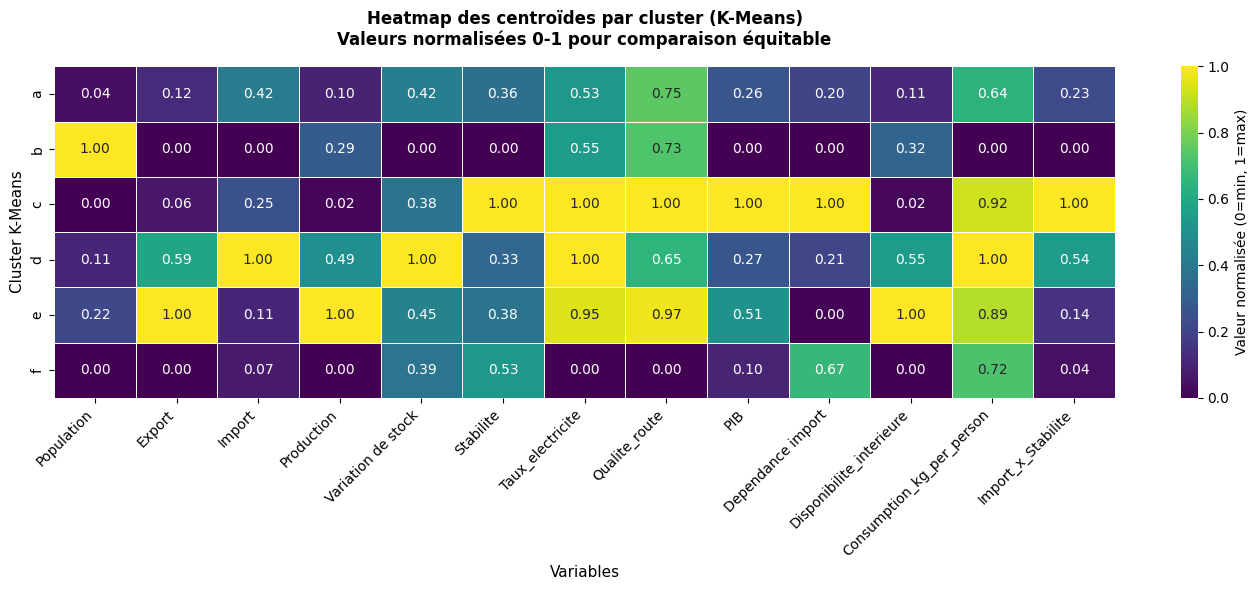

💾 Graphique sauvegardé : heatmap_clusters_kmeans.png


In [159]:
from sklearn.preprocessing import MinMaxScaler

# Get the list of numerical features used for clustering, excluding 'Pays' and 'cluster'
variables_analyse = X.drop(columns=['Pays', 'cluster']).columns.tolist()

# Calculate the mean of these features for each cluster
centroids_km_df = X.groupby('cluster')[variables_analyse].mean()

# Scale the centroids for visualization
centroids_km_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(centroids_km_df),
    columns=variables_analyse,
    index=centroids_km_df.index
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(centroids_km_norm,
            annot=True, fmt='.2f',
            cmap='viridis',
            vmin=0, vmax=1,
            linewidths=0.5,
            cbar_kws={'label': 'Valeur normalisée (0=min, 1=max)'},
            ax=ax)
ax.set_title("Heatmap des centroïdes par cluster (K-Means)\nValeurs normalisées 0-1 pour comparaison équitable",
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Variables", fontsize=11)
ax.set_ylabel("Cluster K-Means", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_clusters_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : heatmap_clusters_kmeans.png")

In [182]:
print("### Analyse des Clusters K-Means via Heatmap des Centroïdes ###\n")

# centroids_km_norm DataFrame est déjà disponible et contient les valeurs normalisées

for cluster_label, row in centroids_km_norm.iterrows():
    print(f"--- Cluster {cluster_label.upper()} ---")

    # Identifier les variables avec les valeurs les plus élevées (proches de 1)
    high_values = row[row > 0.8].sort_values(ascending=False)

    # Identifier les variables avec les valeurs les plus basses (proches de 0)
    low_values = row[row < 0.2].sort_values()

    if not high_values.empty:
        print("  Variables avec des valeurs élevées (caractéristiques dominantes) :")
        for var, val in high_values.items():
            print(f"    - {var}: {val:.2f}")
    else:
        print("  Aucune variable avec des valeurs très élevées pour ce cluster.")

    if not low_values.empty:
        print("  Variables avec des valeurs faibles (caractéristiques moins présentes) :")
        for var, val in low_values.items():
            print(f"    - {var}: {val:.2f}")
    else:
        print("  Aucune variable avec des valeurs très faibles pour ce cluster.\n")
    print("\n")

print("Cette analyse permet de comprendre le profil distinct de chaque cluster K-Means en fonction des variables initiales, en identifiant celles qui sont particulièrement fortes ou faibles au sein de chaque groupe.")

### Analyse des Clusters K-Means via Heatmap des Centroïdes ###

--- Cluster A ---
  Aucune variable avec des valeurs très élevées pour ce cluster.
  Variables avec des valeurs faibles (caractéristiques moins présentes) :
    - Population: 0.04
    - Production: 0.10
    - Disponibilite_interieure: 0.11
    - Export: 0.12


--- Cluster B ---
  Variables avec des valeurs élevées (caractéristiques dominantes) :
    - Population: 1.00
  Variables avec des valeurs faibles (caractéristiques moins présentes) :
    - Export: 0.00
    - Import: 0.00
    - Variation de stock: 0.00
    - Stabilite: 0.00
    - PIB: 0.00
    - Dependance import: 0.00
    - Consumption_kg_per_person: 0.00
    - Import_x_Stabilite: 0.00


--- Cluster C ---
  Variables avec des valeurs élevées (caractéristiques dominantes) :
    - Stabilite: 1.00
    - Taux_electricite: 1.00
    - Import_x_Stabilite: 1.00
    - Dependance import: 1.00
    - PIB: 1.00
    - Qualite_route: 1.00
    - Consumption_kg_per_person: 0.92
  V

In [181]:
for cluster_label in X['cluster'].unique():
    # on fait une selection
    sub_df = X.loc[X.cluster == cluster_label]

    # le cluster en question
    print(f"cluster : {cluster_label}")

    # on extrait les noms des pays de chaque ligne
    pays_list = sub_df['Pays'].values

    # on transforme en str
    txt = ", ".join(pays_list)

    # on print
    print(txt)
    print("\n\n")

cluster : a
Afrique du Sud, Algérie, Allemagne, Arabie saoudite, Argentine, Colombie, Espagne, France, Iran (République islamique d'), Italie, Maroc, Ouganda, Pologne, République de Corée, République-Unie de Tanzanie, Royaume-Uni de Grande-Bretagne et d'Irlande du Nord, Thaïlande, Viet Nam



cluster : f
Albanie, Angola, Antigua-et-Barbuda, Arménie, Azerbaïdjan, Bahamas, Barbade, Bélarus, Belize, Bénin, Bolivie (État plurinational de), Bosnie-Herzégovine, Botswana, Bulgarie, Burkina Faso, Cabo Verde, Cambodge, Chili, Chypre, Congo, Costa Rica, Croatie, Cuba, Djibouti, Dominique, El Salvador, Équateur, Estonie, Eswatini, Fidji, Gabon, Gambie, Géorgie, Ghana, Grèce, Grenade, Guatemala, Guinée, Guinée-Bissau, Guyana, Haïti, Honduras, Hongrie, Îles Salomon, Jamaïque, Jordanie, Kazakhstan, Kirghizistan, Kiribati, Koweït, Lesotho, Lettonie, Libéria, Lituanie, Macédoine du Nord, Madagascar, Malaisie, Malawi, Maldives, Malte, Maurice, Mauritanie, Mongolie, Monténégro, Mozambique, Namibie, Népa

In [160]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop(columns=['cluster', 'Pays']))

In [161]:
pca = PCA(n_components=8)
pca.fit(X_scaled)

PCA(n_components=8)

In [162]:
X_proj_array = pca.transform(X_scaled)
# Rajout des pays selon les clusters
multi_index = pd.MultiIndex.from_arrays([names, labels], names=['Pays', 'Cluster'])
X_proj = pd.DataFrame(X_proj_array, columns = [f"PC{i+1}" for i in range(pca.n_components)], index=multi_index)
X_proj[:]

,,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Pays,Cluster,,,,,,,,
Afrique du Sud,a,0.859294,-0.805113,-0.492973,-0.412031,-0.555588,1.538678,-1.600433,-1.023412
Albanie,f,-0.443885,0.442995,0.042020,-0.204625,-0.428548,-0.011832,-0.071438,0.837398
Algérie,a,-0.770071,-1.314909,-0.508917,-1.167145,0.223075,0.247350,-0.327633,1.087198
Allemagne,a,3.153862,2.013735,-2.242594,-0.106272,-1.765984,0.626979,-0.409302,-0.018573
Angola,f,-1.572188,-1.098852,-1.180895,1.562419,-0.694238,0.395354,-0.336301,-0.977924
...,...,...,...,...,...,...,...,...,...
Uruguay,f,-0.314610,0.549675,0.557060,-0.909824,0.171475,-0.770478,0.356367,0.498095
Vanuatu,f,-1.383639,-0.021009,0.101649,1.525034,0.128189,-0.359679,0.704661,-0.230267
Viet Nam,a,0.344534,-0.259790,-0.734012,-0.572561,-0.247427,0.806464,0.010958,0.435057


In [163]:
#Classification hierarchique
Z = linkage(X_scaled, method='ward')

In [164]:
def display_factorial_planes(   X_proj,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_proj)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    else:
        # Convert labels to list to ensure positional indexing works
        if isinstance(labels, pd.Series):
            labels = labels.tolist()

    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

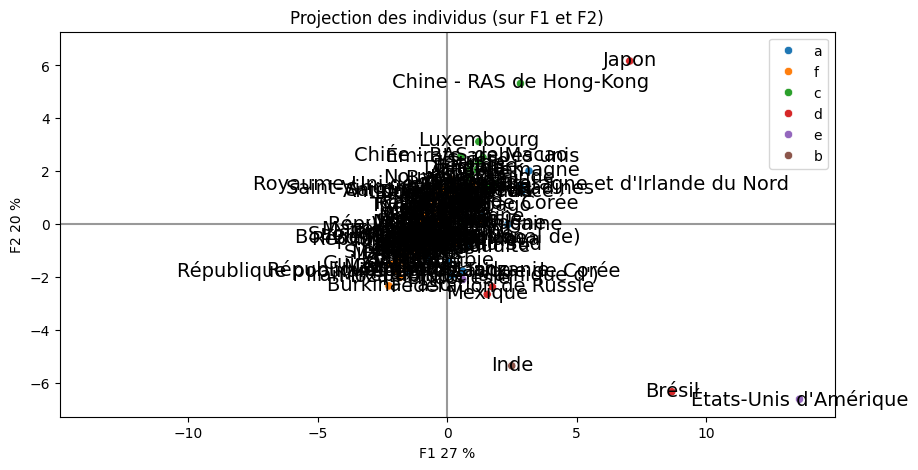

In [227]:
x_y_components = (0, 1)
display_factorial_planes(X_proj, x_y_components, pca, labels=names, figsize=(10,5), clusters=labels, marker="carré")

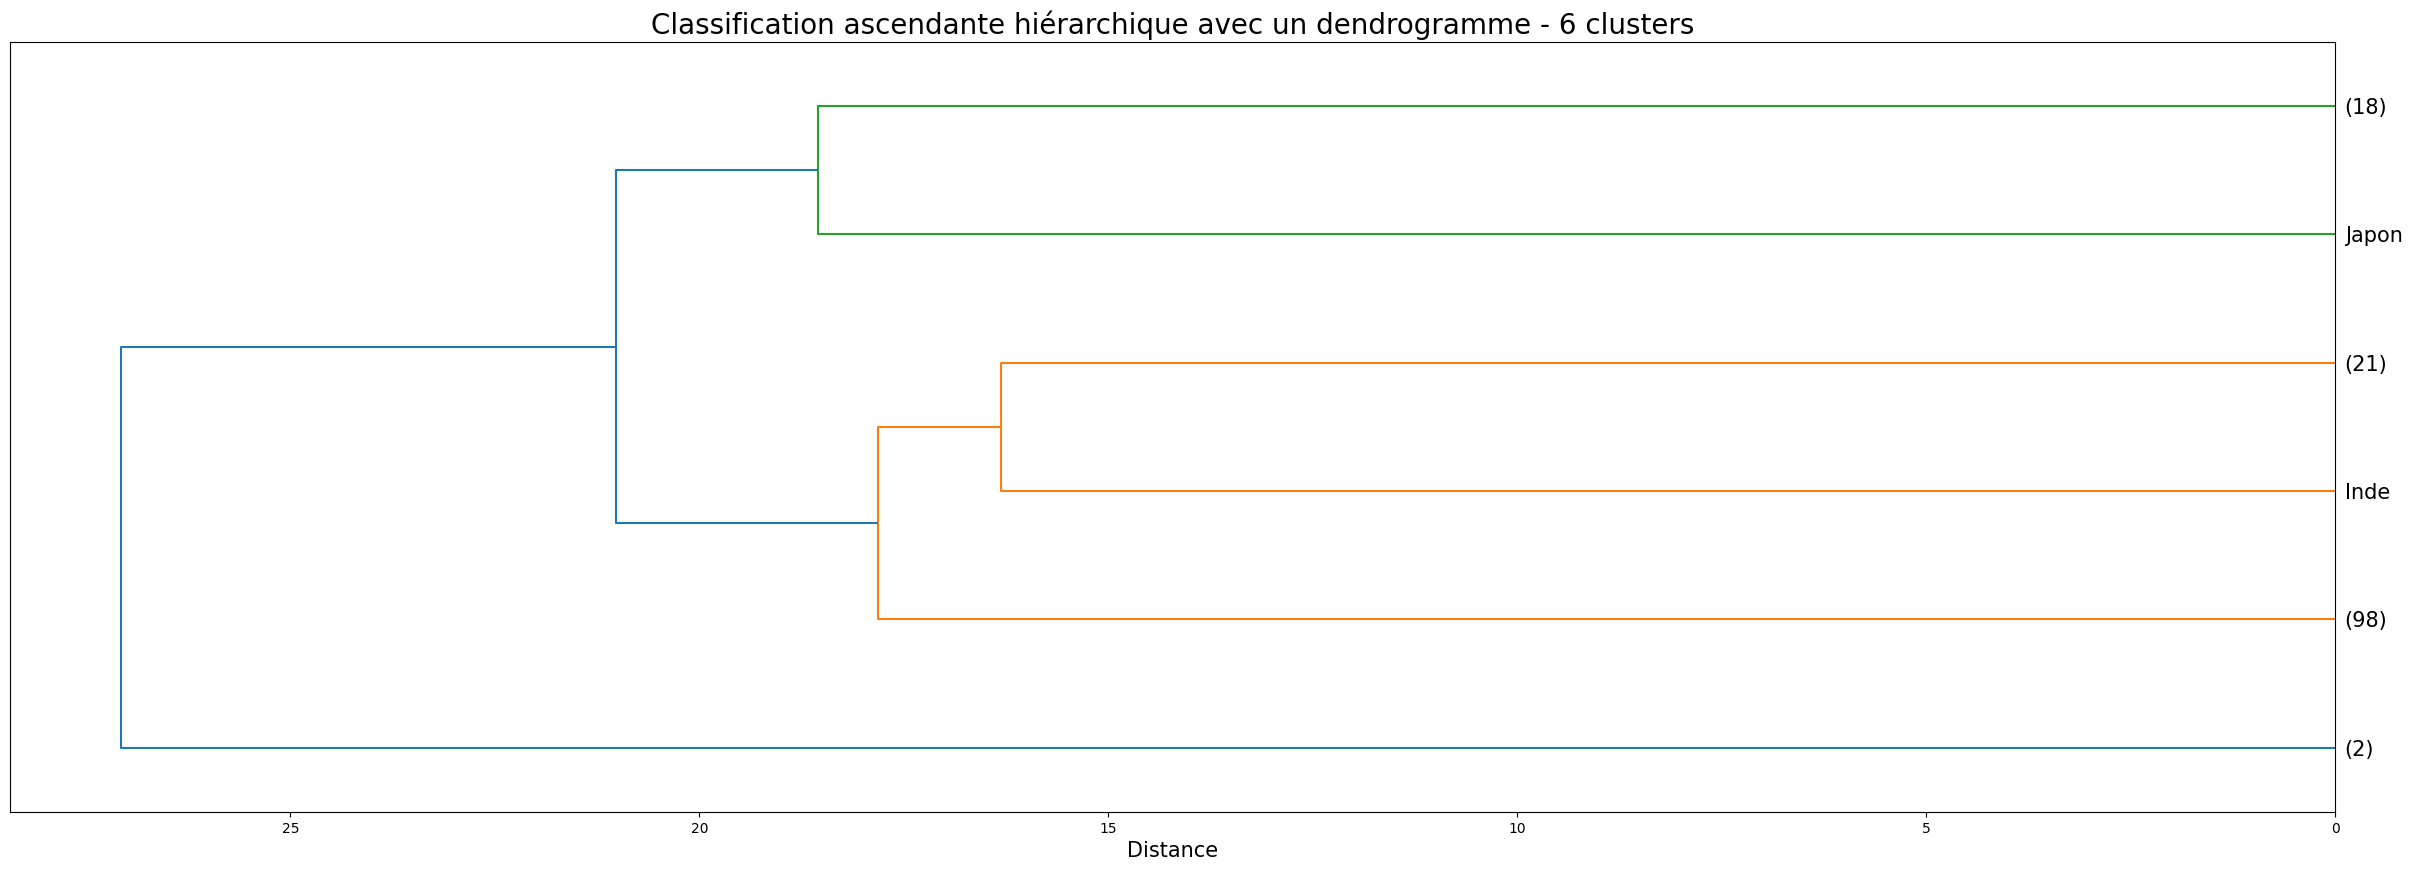

In [166]:
fig = plt.figure(figsize=(30,10))
plt.title('Classification ascendante hiérarchique avec un dendrogramme - 6 clusters', fontsize=20)
plt.xlabel('Distance', fontsize=15)

dendrogram(Z, labels = names.tolist(), p=6, truncate_mode='lastp', leaf_font_size=15, orientation='left')
plt.savefig("dendrogramme_clusters5.png")
plt.show()

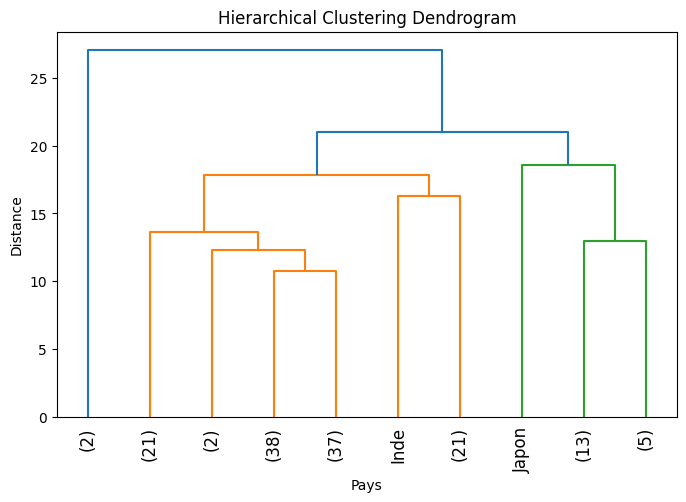

In [221]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
dendrogram(Z, p=10, truncate_mode="lastp", ax=ax, labels=names.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Pays")
plt.ylabel("Distance")
plt.show()

In [213]:
#clusters des pays selon CAH
print("📊 Analyse des dernières fusions (ordre décroissant) :")
print()
print(f"{'Fusion':<10} {'Distance (hauteur)':<25} {'Saut par rapport au suivant'}")
print("-" * 60)
derniers = Z[-10:][::-1]
for i, fusion in enumerate(derniers[:-1]):
    dist_actuelle = fusion[2]
    dist_suivante = derniers[i+1][2]
    saut = dist_actuelle - dist_suivante
    print(f"{len(Z)-i:<10} {dist_actuelle:<25.3f} +{saut:.3f}")

print()
print("🎯 Le plus grand saut indique le nombre optimal de clusters.")
print("   Choisissons 10 clusters pour la CAH (visible dans le dendrogramme).")



📊 Analyse des dernières fusions (ordre décroissant) :

Fusion     Distance (hauteur)        Saut par rapport au suivant
------------------------------------------------------------
140        27.075                    +6.061
139        21.014                    +2.467
138        18.547                    +0.731
137        17.816                    +1.506
136        16.310                    +2.675
135        13.635                    +0.683
134        12.952                    +0.683
133        12.269                    +1.495
132        10.773                    +1.181

🎯 Le plus grand saut indique le nombre optimal de clusters.
   Choisissons 10 clusters pour la CAH (visible dans le dendrogramme).


In [169]:
# Application de la CAH avec 6 clusters
n_clusters_cah = 6
clusters_cah = fcluster(Z, n_clusters_cah, criterion='maxclust')

# Création d'un DataFrame avec les clusters
df_cah = df[variables_analyse].copy()
df_cah['cluster_CAH'] = clusters_cah
df_cah.index = names

print(f"✅ CAH appliquée avec {n_clusters_cah} clusters")
print()
print("📊 Répartition des pays par cluster :")
repartition = df_cah['cluster_CAH'].value_counts().sort_index()
for cluster, nb in repartition.items():
    print(f"   Cluster {cluster} : {nb} pays")

✅ CAH appliquée avec 6 clusters

📊 Répartition des pays par cluster :
   Cluster 1 : 2 pays
   Cluster 2 : 98 pays
   Cluster 3 : 21 pays
   Cluster 4 : 1 pays
   Cluster 5 : 18 pays
   Cluster 6 : 1 pays


In [176]:
CAH_pays = df_cah.reset_index().groupby('cluster_CAH')['Pays'].apply(list)
display(CAH_pays)

,Pays
cluster_CAH,
1,"[Brésil, États-Unis d'Amérique]"
2,"[Afrique du Sud, Albanie, Algérie, Antigua-et-..."
3,"[Angola, Bénin, Burkina Faso, Congo, Djibouti,..."
4,[Inde]
5,"[Allemagne, Australie, Autriche, Belgique, Can..."
6,[Japon]


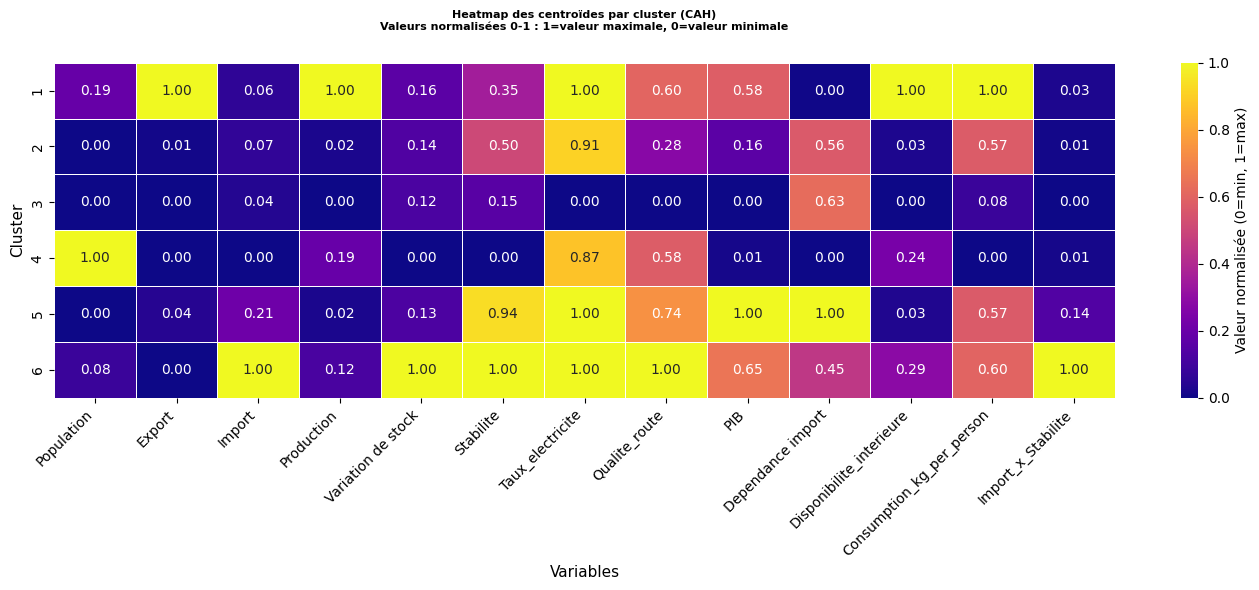

💾 Graphique sauvegardé : heatmap_clusters_cah.png


In [224]:
# Centroïdes (valeurs moyennes de chaque variable pour chaque cluster)
centroids_cah = df_cah.groupby('cluster_CAH')[variables_analyse].mean()

# Normalisation des centroïdes pour la heatmap (pour éviter l'effet de taille)
from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
centroids_norm = pd.DataFrame(
    scaler_viz.fit_transform(centroids_cah),
    columns=variables_analyse,
    index=centroids_cah.index
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(centroids_norm,
            annot=True,
            fmt='.2f',
            cmap='plasma',
            vmin=0, vmax=1,
            linewidths=0.5,
            cbar_kws={'label': 'Valeur normalisée (0=min, 1=max)'},
            ax=ax)

ax.set_title("Heatmap des centroïdes par cluster (CAH)\n"
             "Valeurs normalisées 0-1 : 1=valeur maximale, 0=valeur minimale\n",
             fontsize=8, fontweight='bold', pad=15)
ax.set_xlabel("Variables", fontsize=11)
ax.set_ylabel("Cluster", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_clusters_cah.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé : heatmap_clusters_cah.png")


In [228]:
print("### Pays dans le Cluster 5 (CAH) ###")
print(CAH_pays[5])
print("\n### Pays dans le Cluster 6 (CAH) ###")
print(CAH_pays[6])

### Pays dans le Cluster 5 (CAH) ###
['Allemagne', 'Australie', 'Autriche', 'Belgique', 'Canada', 'Chine - RAS de Hong-Kong', 'Chine - RAS de Macao', 'Danemark', 'Émirats arabes unis', 'Finlande', 'Irlande', 'Islande', 'Luxembourg', 'Norvège', 'Nouvelle-Zélande', "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'Suède', 'Suisse']

### Pays dans le Cluster 6 (CAH) ###
['Japon']
